Note: May contain errors. For the runnable version, please refer to `models.py`.

## 1. Utils

Elemental modules in transformer

In [1]:
import torch
import torch.nn as nn
import math

### Positional Encoding

$$
\begin{align}
PE_{(\text{posi}, 2i)} &= \sin(\text{posi} / 10000^{2i / d_{\text{model}}}) \\
PE_{(\text{posi}, 2i+1)} &= \cos(\text{posi} / 10000^{2i / d_{\text{model}}})
\end{align}
$$

Note:
- Why we use $\sin$ and $\cos$ for different dimension: The choice of $\sin$ and $\cos$ enables the model to learn relative positions. That is, we can transform from one position to another using a simple linear function.
- Why we use $10000^{2i / d_{\text{model}}}$: We use $2i$ so that different dimensions change at different speed when position changes, making it easier for the model to capture both short-range and long-range dependencies.

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        """
        input:
        - d_model: length of the word vectors
        - max_len: max length of the sentences
        """
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -math.log(10000.0) / d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

### Multi-Head Attention

$$
\text{Attention}(Q, K, V) = \text{softmax}(\frac{Q K^T}{\sqrt{d_k}}) V
$$

In practice, we use `chunk + transpose` to better utilize GPU resources.

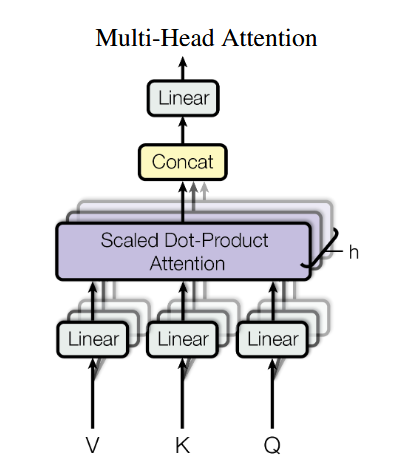

In [7]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model % num_head != 0 !"
        self.d_k = d_model // num_heads
        self.num_heads = num_heads

        self.qkv = nn.Linear(d_model, d_model * 3)
        self.out = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        batch_size, length, _ = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(batch_size, length, self.num_heads, self.d_k).transpose(1, 2)
        k = k.view(batch_size, length, self.num_heads, self.d_k).transpose(1, 2)
        v = v.view(batch_size, length, self.num_heads, self.d_k).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores.masked_fill_(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = attn @ v
        out = out.transpose(1, 2).contiguous().view(batch_size, length, -1)
        return self.out(out)

### Feed Forward

In [8]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.ff(x)

### Transformer Layer

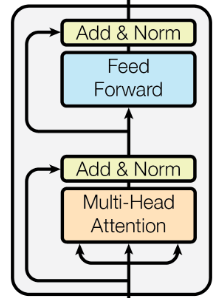

In pratice, we adopt Pre-Norm instead of Post-Norm, which made gradient more stable.

In [9]:
class TransformerLayer(nn.Module):
    """
    Architecture:
    x -> Norm -> Attn -> Dropout -> Add -> Norm -> FFN -> Dropout -> Add 
    """
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = x + self.dropout(self.attn(self.norm1(x), mask))
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x

## 2. MiniBERT

BERT is an encoder-only model.

In [10]:
class MiniBERT(nn.Module):
    def __init__(self, vocab_size, d_model=256, num_heads=3, 
                 d_ff=512, n_layers=6, max_len=128, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([TransformerLayer(d_model, num_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)
        self.mask_token_id = vocab_size - 1 # Assume the end of the word list is [MASK]

    def forward(self, input_ids, mask=None):
        x = self.embed(input_ids)
        x = self.pos(x)
        for layer in self.layers:
            x = layer(x, mask)
        return self.head(self.norm(x))

## 3. MiniGPT

GPT is a decoder-only model.

In [11]:
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model=256, num_heads=3, d_ff=512, n_layers=6, max_len=128, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([TransformerLayer(d_model, num_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids):
        batch_size, length = input_ids.shape

        # Two unsqueeze: one for batch_size, one for num_heads
        causal_mask = torch.tril(torch.ones(length, length, device=input_ids.device)).unsqueeze(0).unsqueeze(0)

        
        x = self.embed(input_ids)
        x = self.pos(x)
        for layer in self.layers:
            x = layer(x, causal_mask)
        return self.head(self.norm(x))